### Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Dowloading/Loading Dataset

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kandij/mall-customers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\fbase\AppData\Local\Temp\ipykernel_37552\1782252800.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


### Data Overview

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Cleaning and EDA

In [4]:
df = df.rename(columns={"Annual Income (k$)":"annual_income",
                        "Spending Score (1-100)":"spending_score"}
)

In [5]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'annual_income', 'spending_score'], dtype='str')

In [6]:
df.columns = ['customerid','sex','age',"annual_income","spending_score"]

In [7]:
df.columns

Index(['customerid', 'sex', 'age', 'annual_income', 'spending_score'], dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      200 non-null    int64
 1   sex             200 non-null    str  
 2   age             200 non-null    int64
 3   annual_income   200 non-null    int64
 4   spending_score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


<Axes: >

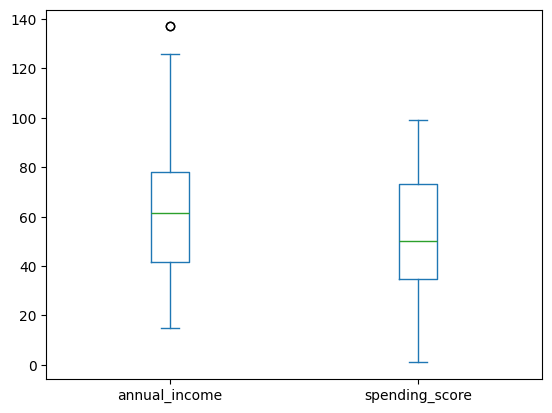

In [9]:
df[['annual_income','spending_score']].plot(kind="box")

<Axes: ylabel='Frequency'>

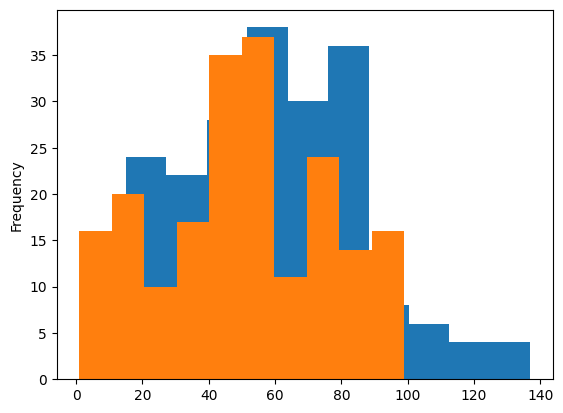

In [10]:
df['annual_income'].plot(kind="hist")
df['spending_score'].plot(kind="hist")

## Data PreProcessing and Model training

In [11]:
scaler = StandardScaler()

In [12]:
X_scaled = scaler.fit_transform(df.iloc[:,3:])

In [13]:
model1 = KMeans()

In [14]:
model1.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
labels = model1.labels_

In [16]:
labels

array([0, 4, 7, 4, 0, 4, 7, 4, 7, 4, 7, 4, 7, 4, 7, 4, 0, 4, 0, 4, 0, 4,
       7, 4, 7, 4, 0, 4, 0, 4, 7, 4, 7, 4, 7, 4, 7, 4, 0, 4, 0, 4, 0, 3,
       0, 4, 3, 0, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 5, 1, 5, 6, 5, 6, 5, 6, 5,
       6, 5], dtype=int32)

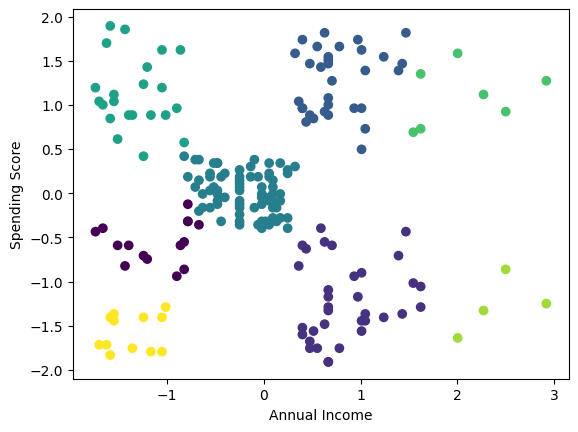

In [17]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

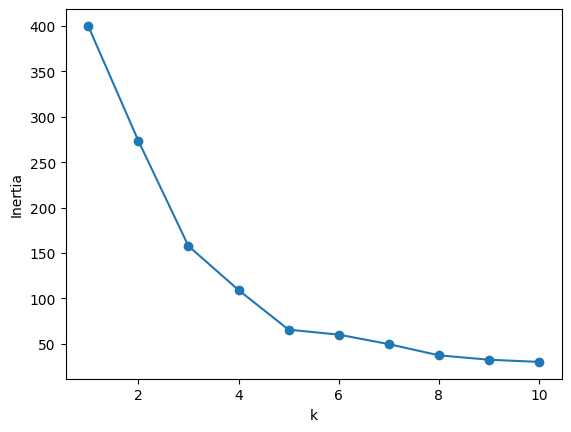

In [18]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

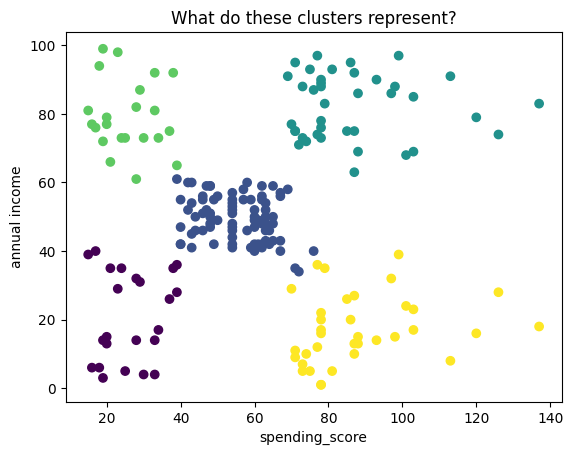

In [22]:
model2 = KMeans(n_clusters=5)
model2.fit(X_scaled)

plt.scatter(df.annual_income,df.spending_score,c=model2.labels_,cmap='viridis')
plt.xlabel("spending_score")
plt.ylabel("annual income")
plt.title("What do these clusters represent?")
plt.show()

In [24]:
df['Cluster'] = model2.labels_
df.groupby('Cluster')[['age', 'annual_income', 'spending_score']].mean()

,age,annual_income,spending_score
Cluster,,,
0,45.217391,26.304348,20.913043
1,42.716049,55.296296,49.518519
2,32.692308,86.538462,82.128205
3,25.272727,25.727273,79.363636
4,41.114286,88.200000,17.114286


Adding `age` to the dataset

In [37]:
X_scaled2 = scaler.fit_transform(df[['age','annual_income','spending_score']])

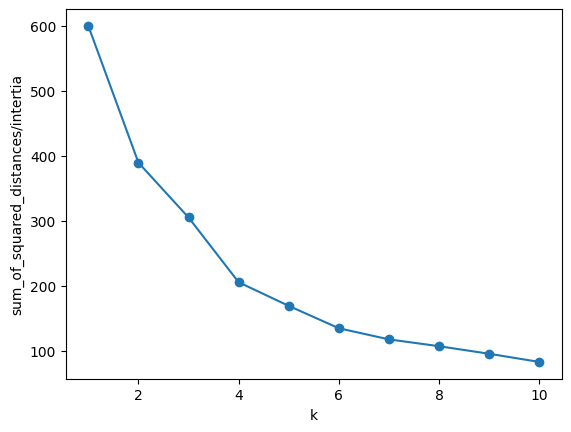

In [40]:
sum_of_squared_distances = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(X_scaled2)
    sum_of_squared_distances.append(km.inertia_)

plt.plot(np.arange(1,11),sum_of_squared_distances,marker='o')
plt.xlabel('k')
plt.ylabel('sum_of_squared_distances/intertia')
plt.show()

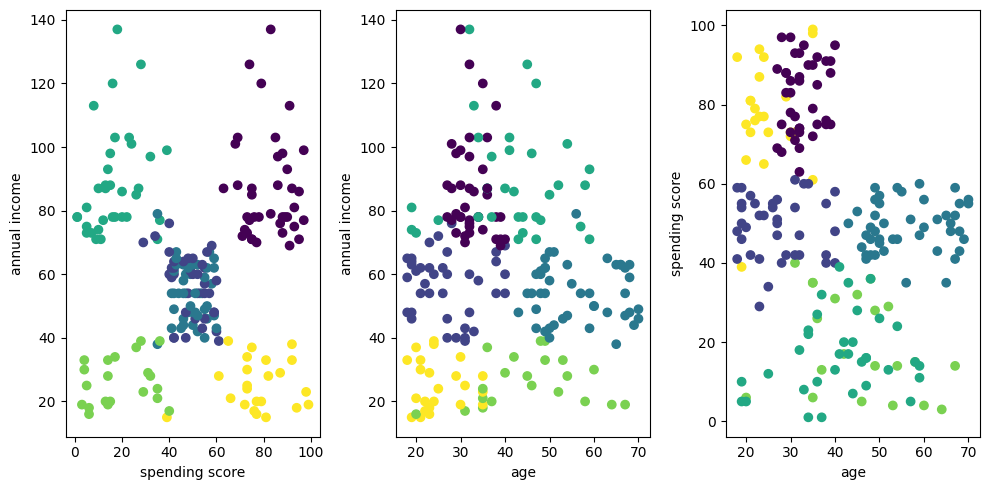

In [46]:
model3 = KMeans(n_clusters=6)
model3.fit(X_scaled2)

fig,ax = plt.subplots(ncols=3, nrows=1, figsize=(10,5))
ax = ax.flatten()

ax[0].scatter(df.spending_score,df.annual_income,c=model3.labels_,cmap='viridis')
ax[0].set_xlabel('spending score')
ax[0].set_ylabel('annual income')

ax[1].scatter(df.age,df.annual_income,c=model3.labels_,cmap='viridis')
ax[1].set_xlabel('age')
ax[1].set_ylabel('annual income')

ax[2].scatter(df.age,df.spending_score,c=model3.labels_,cmap='viridis')
ax[2].set_xlabel('age')
ax[2].set_ylabel('spending score')

plt.tight_layout()
plt.show()

## Dataset 2 - Practice

### Data Downloading

In [27]:
# Set the path to the file you'd like to load
file_path = "student_study_habits.csv"

# Load the latest version
df2 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prekshad2166/student-study-habits",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\fbase\AppData\Local\Temp\ipykernel_37552\1997413468.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df2 = kagglehub.load_dataset(


### Data Overview


In [ ]:
df2.head()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [52]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   study_hours_per_week            500 non-null    float64
 1   sleep_hours_per_day             500 non-null    float64
 2   attendance_percentage           500 non-null    float64
 3   assignments_completed           500 non-null    float64
 4   final_grade                     500 non-null    float64
 5   participation_level_Low         500 non-null    float64
 6   participation_level_Medium      500 non-null    float64
 7   internet_access_Yes             500 non-null    float64
 8   parental_education_High School  500 non-null    float64
 9   parental_education_Master's     500 non-null    float64
 10  parental_education_PhD          500 non-null    float64
 11  extracurricular_Yes             500 non-null    float64
 12  part_time_job_Yes               500 non-null   

### EDA

- study_hours_per_week : average study hours = No of hours spent study / 168 (Total no of hours in a week)
- sleep_hours_per_day : average daily sleep duration = Sum of hours slept perday / No of hours in a week
- attendence_percentage : class percentage rate = (no fo classes attended / total no of classes) * 100
- assignments_completed = no of assignments done / total no of assignments
- participation_level_OHE_columns : participation level in class

Rest of the columns can are easy to understand

In [37]:
columns = df.iloc[:,:5].columns
df2[columns].describe()[1:].style.background_gradient(cmap='magma')

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
mean,0.445603,0.506387,0.684110,0.533556,63.753071
std,0.162325,0.194923,0.214918,0.276109,7.114183
min,0.000000,0.000000,0.000000,0.000000,40.200403
25%,0.327727,0.380942,0.530386,0.333333,58.813933
50%,0.446577,0.505706,0.697383,0.555556,63.822553
75%,0.550575,0.630248,0.844194,0.777778,68.588277
max,1.000000,1.000000,1.000000,1.000000,92.007807


In [51]:

fig = px.box(df2, y = "study_hours_per_week",
             points = "all", notched = True,
             title = "Distribution",
             width=700,
             height=700)

fig.update_traces(marker = dict(size = 4, symbol = "circle-open"))
fig.update_traces(fillcolor = "#000000")
fig.update_layout(template = "plotly_dark")

fig.show()

In [54]:
df2.final_grade.describe()

count    500.000000
mean      63.753071
std        7.114183
min       40.200403
25%       58.813933
50%       63.822553
75%       68.588277
max       92.007807
Name: final_grade, dtype: float64

In [56]:
df2.columns

Index(['study_hours_per_week', 'sleep_hours_per_day', 'attendance_percentage',
       'assignments_completed', 'final_grade', 'participation_level_Low',
       'participation_level_Medium', 'internet_access_Yes',
       'parental_education_High School', 'parental_education_Master's',
       'parental_education_PhD', 'extracurricular_Yes', 'part_time_job_Yes'],
      dtype='str')

<Axes: xlabel='study_hours_per_week', ylabel='sleep_hours_per_day'>

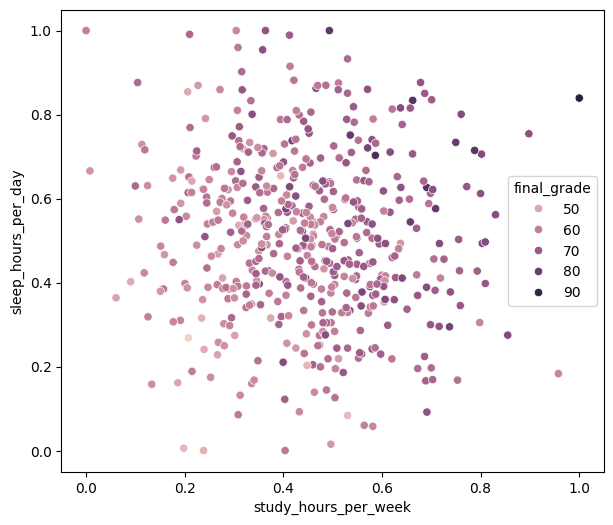

In [68]:
plt.figure(figsize=(7,6))
sns.scatterplot(df2,x='study_hours_per_week',y='sleep_hours_per_day',hue='final_grade')

In [70]:
df.corr().style.background_gradient(cmap='magma')

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
study_hours_per_week,1.000000,-0.075378,-0.064476,0.012121,0.517297,-0.042347,0.053687,0.022966,0.010111,0.004026,0.062669,-0.012191,0.024995
sleep_hours_per_day,-0.075378,1.000000,0.078977,-0.040785,0.237757,0.002322,0.006176,0.019395,-0.127791,0.020758,0.038618,-0.031848,0.018154
attendance_percentage,-0.064476,0.078977,1.000000,-0.049445,0.196920,-0.111465,0.040078,-0.015378,0.005628,0.066900,-0.013727,-0.013577,-0.021553
assignments_completed,0.012121,-0.040785,-0.049445,1.000000,0.389298,0.054175,-0.004972,0.005433,0.013700,-0.056510,-0.003839,-0.006331,0.071540
final_grade,0.517297,0.237757,0.196920,0.389298,1.000000,-0.337384,-0.013224,0.107834,-0.181262,0.079005,0.203578,0.000821,-0.160734
participation_level_Low,-0.042347,0.002322,-0.111465,0.054175,-0.337384,1.000000,-0.487273,0.049513,0.089210,-0.071573,-0.072036,0.036724,-0.020529
participation_level_Medium,0.053687,0.006176,0.040078,-0.004972,-0.013224,-0.487273,1.000000,0.020721,-0.061948,0.131868,0.031697,0.003657,0.004545
internet_access_Yes,0.022966,0.019395,-0.015378,0.005433,0.107834,0.049513,0.020721,1.000000,-0.061479,-0.022244,0.006912,-0.026443,-0.022273
parental_education_High School,0.010111,-0.127791,0.005628,0.013700,-0.181262,0.089210,-0.061948,-0.061479,1.000000,-0.328829,-0.175992,0.020334,-0.032479
parental_education_Master's,0.004026,0.020758,0.066900,-0.056510,0.079005,-0.071573,0.131868,-0.022244,-0.328829,1.000000,-0.158067,-0.043680,0.081784


In [82]:
model4 = KMeans(n_clusters=4)
model4.fit(df2.drop(columns='final_grade'))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [83]:
df2['cluster_labels']= model4.labels_

In [84]:
df2.groupby('cluster_labels')[['study_hours_per_week','sleep_hours_per_day','attendance_percentage','assignments_completed','final_grade']].mean()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
cluster_labels,,,,,
0,0.441535,0.477702,0.701849,0.519026,63.407898
1,0.442316,0.515147,0.655880,0.543275,65.209110
2,0.461871,0.553567,0.735135,0.568306,65.552643
3,0.447796,0.502948,0.680821,0.515642,60.490683


hmm non-interpretable

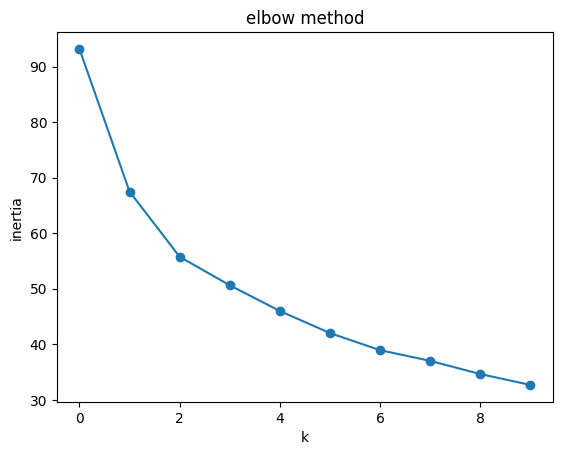

In [91]:
inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit(df2.iloc[:,:4])
    inertia.append(km.inertia_)

plt.plot(np.arange(len(inertia)),inertia,marker='o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('elbow method')
plt.show()

In [92]:
model5 = KMeans(n_clusters=2)
model5.fit(df2.iloc[:,:4])
df2['cluster_labels']= model5.labels_

In [93]:
df2.groupby('cluster_labels')[['study_hours_per_week','sleep_hours_per_day','attendance_percentage','assignments_completed','final_grade']].mean()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
cluster_labels,,,,,
0,0.443285,0.503344,0.676456,0.747703,65.734211
1,0.448237,0.509847,0.692810,0.290123,61.501005


## Dataset 3 - Practice

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "carrie1/ecommerce-data",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


C:\Users\fbase\AppData\Local\Temp\ipykernel_22628\2325809109.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


### Data Exploration

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [8]:
df.Description.value_counts()[:10]

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

In [ ]:
df.Quantity.agg(['min','max'])
# What?

min   -80995
max    80995
Name: Quantity, dtype: int64

I want to see the range of values in Quantity 

<Axes: >

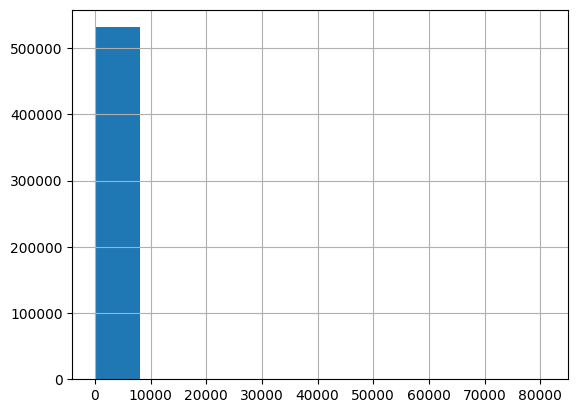

In [19]:
df.query('Quantity > 0').Quantity.hist()

(array([5.31282e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00]),
 array([1.00000e+00, 8.10040e+03, 1.61998e+04, 2.42992e+04, 3.23986e+04,
        4.04980e+04, 4.85974e+04, 5.66968e+04, 6.47962e+04, 7.28956e+04,
        8.09950e+04]),
 <BarContainer object of 10 artists>)

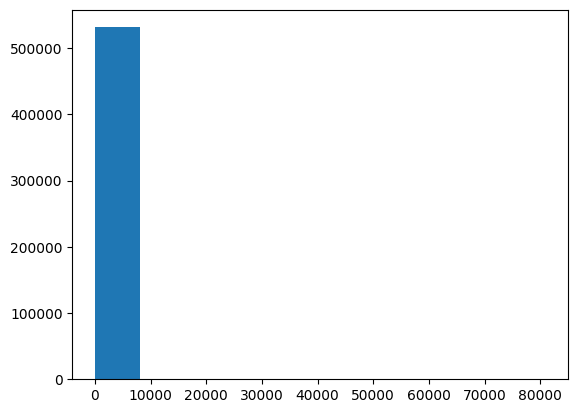

In [ ]:
plt.hist(df.loc[df.Quantity>0,'Quantity'])
# Strange why does it show only one bar

<Axes: >

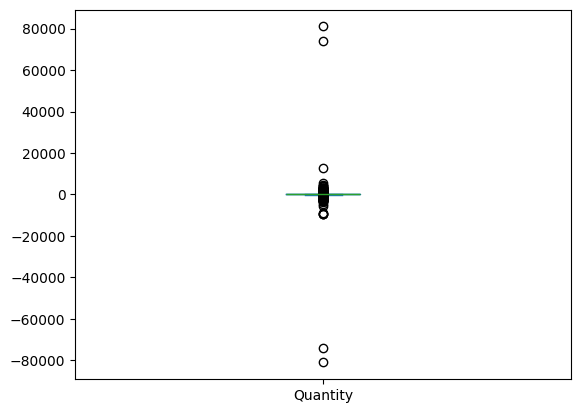

In [18]:
df.Quantity.plot(kind='box')

Have been unable to because of Outliers and histogram behaving strangely

In [ ]:
df.Quantity.unique() #Can't believe that this array is giving me a beter idea of distribution than the plots
# Whats the negative values for does it imply that bought = +ve and sold = -ve ?

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     56,     72,    200,
          600,    480,     -6,     14,     -2,     11,     33,     13,
           -4,     -5,     -7,     -3,     70,    252,     60,    216,
          384,    -10,     27,     15,     22,     19,     17,     21,
           34,     47,    108,     52,  -9360,    -38,     75,    270,
           42,    240,     90,    320,   1824,    204,     69,    -36,
         -192,   -144,    160,   2880,   1400,     39,    -48,    -50,
           26,   1440,     31,     82,     78,     97,     98,     35,
           57,    -20,    110,    -22,    -30,    -70,   -130,    -80,
         -120,    -40,    -25,    -14,    -15,    -69,   -140,   -320,
      